In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import pandas as pd
from tqdm import tqdm
from scipy.optimize import curve_fit

In [41]:
data_dir = '/home/kale-chen/Documents/PET/TPPT2026/data/hvertpgd.bin'
save_dir = '/home/kale-chen/Documents/PET/Sensitivity Normalization/plots'
num_cols, data_size = 4, 2
num_rows = os.path.getsize(data_dir) // (num_cols * data_size)
data = np.memmap(data_dir, dtype=np.int16, mode='r', shape=(num_rows, num_cols))
print(num_rows,)
print(data[0:5])

22595328
[[  433  2885   508     0]
 [  494  2341 -1924     0]
 [  709  2420 -6310     0]
 [  509  2385   513     0]
 [  615  2385   255     0]]


In [43]:
# Raw backprojection method
mapdf = pd.read_csv('/home/kale-chen/Documents/PET/TPPT_Scanner_map_adjusted.csv', usecols=[0,1,2,3,4,5], header=None)
map = mapdf.to_numpy()[:, 0:3]
#sensimgcorrection = np.fromfile('/home/kale-chen/Documents/PET/Sensitivity Normalization/sensimgs/sensimgcorrection.bin', dtype = np.float32)
xedges = np.linspace(-180, 180, 361)
yedges = np.linspace(-180, 180, 361)
def siddon(x1, y1, x2, y2, x_edges, y_edges, count):
    dx = x2 - x1
    dy = y2 - y1
    total_length = np.hypot(dx, dy)
    alphas = [0.0, 1.0]
    if dx != 0:
        ax = (x_edges - x1) / dx
        alphas.extend(ax[(ax > 0) & (ax < 1)])
    if dy != 0:
        ay = (y_edges - y1) / dy
        alphas.extend(ay[(ay > 0) & (ay < 1)])
    alphas = np.unique(np.sort(alphas))
    contribution = np.zeros((len(x_edges) - 1, len(y_edges) - 1))
    for a0, a1 in zip(alphas[:-1], alphas[1:]):
        amid = (a0 + a1) / 2
        xmid = x1 + amid * dx
        ymid = y1 + amid * dy
        ix = np.searchsorted(x_edges, xmid) - 1
        iy = np.searchsorted(y_edges, ymid) - 1
        if (0 <= ix < len(x_edges) - 1 and 0 <= iy < len(y_edges) - 1):
            length = (a1 - a0) * total_length
            contribution[iy, ix] += length * count
    return contribution
def plot_img(img, fignum, name, title, save = False):
    plt.figure(fignum, figsize = (5, 5))
    norm_img = img #/ sensimg
    norm_img = norm_img / np.max(norm_img)
    norm_img = np.flip(norm_img, axis = 0)
    max_pixel = np.unravel_index(np.argmax(norm_img), norm_img.shape)
    max_pos = (-180 + max_pixel[1], 180 - max_pixel[0])
    plt.imshow(norm_img, cmap = 'hot', aspect = 'auto', vmin = 0, vmax = 1, extent = [-180, 180, -180, 180])
    #plt.plot(max_pos[0], max_pos[1], 'ro', color = 'blue', markersize = 4, alpha = 0.5)
    plt.xticks(np.linspace(-150, 150, 11))
    plt.yticks(np.linspace(-150, 150, 11))
    plt.title(title)
    if save:
        plt.savefig(os.path.join(save_dir, f'{name}.png'))
    return max_pos
topring = map[map[:, 2] == np.max(map[:, 2])]
topringL = topring[topring[:, 0] < 0]
topringR = topring[topring[:, 0] > 0]

yL_to_idx = {y: idx for idx, y in enumerate(topringL[:, 1])}
yR_to_idx = {y: idx for idx, y in enumerate(topringR[:, 1])}


#sensimg = np.zeros((360, 360))
#for i in tqdm(range(96)):
#    for j in range(96):
#        sensimg += siddon(topringL[i][0], topringL[i][1], topringR[j][0], topringR[j][1], xedges, yedges, 1)
#sensimg[sensimg == 0] = 1


In [44]:
duration = 600
windows = 30
offset = 0
timeranges = [(w * duration // windows, w * duration // windows + 1) for w in range(windows)]
#timeranges = [(0, 30+offset), (30+offset, 60+offset), (60+offset, 90+offset), (90+offset, 120+offset), (120+offset, 150+offset), (150+offset, 180+offset)]
#timeranges = [(0, 600)]
imgs = np.zeros((360, 360, windows))
for w in tqdm(range(windows)):
    timerange = timeranges[w]
    eventcounts = np.zeros((3072 * 3072), dtype = np.int32)
    for i in range(0, num_rows, 1000000):
        chunk = data[i:i+1000000]
        if num_cols == 4:
            mask = (chunk[:, 3] >= timerange[0]) & (chunk[:, 3] < timerange[1])
            chunk = chunk[mask]
            ids = np.asarray(chunk[:, [0, 1]], dtype = np.int32)
            indices = ids[:, 0] * 3072 + ids[:, 1]
            np.add.at(eventcounts, indices, 1)
        else:
            mask = (chunk[:, 5] >= timerange[0]) & (chunk[:, 5] < timerange[1])
            chunk = chunk[mask]
            ids = np.asarray(chunk[:, [1, 3]], dtype = np.int32)
            indices = ids[:, 0] * 3072 + ids[:, 1]
            np.add.at(eventcounts, indices, 1)
    eventcounts = eventcounts.reshape((3072, 3072))
    print(np.sum(eventcounts))
    eventcountsuniquepos = np.zeros((len(topringL), len(topringR)), dtype = np.int32)
    for i in range(len(eventcounts)):
        yL = map[i + 3072][1]
        topringidL = yL_to_idx.get(yL)
        for j in range(len(eventcounts[0])):
            yR = map[j][1]
            topringidR = yR_to_idx.get(yR)
            eventcountsuniquepos[topringidL, topringidR] += eventcounts[i, j]
    for row in range(96):
        for col in range(96):
            imgs[:, :, w] += siddon(topringL[row][0], topringL[row][1], topringR[col][0], topringR[col][1], xedges, yedges, eventcountsuniquepos[row, col])
            #siddon(imgs[:, :, w], topringL[row][0], topringL[row][1], topringR[col][0], topringR[col][1], xedges, yedges, eventcountsuniquepos[row, col])

  0%|          | 0/30 [00:00<?, ?it/s]

24421


  3%|▎         | 1/30 [00:18<08:49, 18.25s/it]

27433


  7%|▋         | 2/30 [00:35<08:12, 17.61s/it]

...

 93%|█████████▎| 28/30 [09:08<00:33, 16.63s/it]

28939


 97%|█████████▋| 29/30 [09:24<00:16, 16.49s/it]

25369


100%|██████████| 30/30 [09:42<00:00, 19.42s/it]


In [123]:
# Project from geomask
n = 10
geomask = np.fromfile(f'/home/kale-chen/Documents/PET/Sensitivity Normalization/geomask{n}.bin', dtype = np.bool)
img = np.zeros((360, 360))
eventcounts = geomask.reshape((3072, 3072))
eventcountsuniquepos = np.zeros((len(topringL), len(topringR)), dtype = np.int32)
for i in range(len(eventcounts)):
    yL = map[i + 3072][1]
    topringidL = yL_to_idx.get(yL)
    for j in range(len(eventcounts[0])):
        yR = map[j][1]
        topringidR = yR_to_idx.get(yR)
        eventcountsuniquepos[topringidL, topringidR] += eventcounts[i, j]
for row in tqdm(range(96)):
    for col in range(96):
        img += siddon(topringL[row][0], topringL[row][1], topringR[col][0], topringR[col][1], xedges, yedges, eventcountsuniquepos[row, col])
            

100%|██████████| 96/96 [00:10<00:00,  8.93it/s]


In [64]:
plot_img(boost(img), 0, 'geomask', '', save = False)

NameError: name 'img' is not defined

(np.int64(-100), np.int64(135))

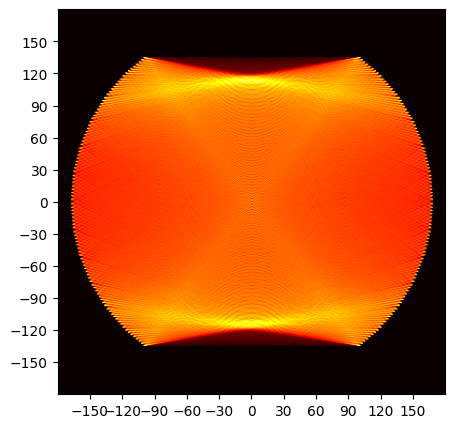

In [40]:
plot_img(boost(imgs[:, :, 0]), 0, 'mcircprojcut1', '', save = False)

In [4]:
sensimg = np.zeros((360, 360))
for i in tqdm(range(96)):
    for j in range(96):
        sensimg += siddon(topringL[i][0], topringL[i][1], topringR[j][0], topringR[j][1], xedges, yedges, 1)
sensimg[sensimg == 0] = 1
#plot_img(sensimg, 0, 'hcenterprojcut2', '', save = False)

100%|██████████| 96/96 [00:09<00:00,  9.63it/s]


In [ ]:
plt.figure(figsize = (10, 10))
sensimg = sensimg / np.mean(sensimg)
sensimg.tofile(os.path.join('Sensitivity Normalization/sensimgs/siddon.bin'))
plt.imshow(sensimg, vmax = 1)
plt.plot([180], [180], 'ro')
plt.show()

NameError: name 'plt' is not defined

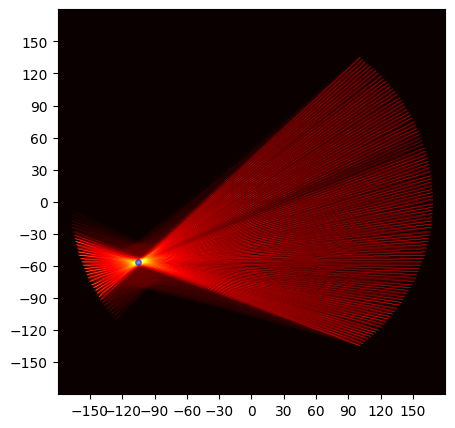

In [10]:
# Preprocessing
def boost(img):
    return np.sqrt(img)
imgs[:, :, 0] = imgs[:, :, 0] / np.max(imgs[:, :, 0])
maxx, maxy = plot_img(boost(imgs[:, :, 10]), 0, 'hcenterprojcut2', '', save = False)
plt.plot(maxx, maxy, 'o', color = 'blue', markersize = 4, alpha = 0.5)

/tmp/ipykernel_3680930/1688320098.py:31: UserWarning: Ignoring specified arguments in this call because figure with num: 0 already exists
  plt.figure(fignum, figsize = (5, 5))


Circle fit: center=(-3.9,-0.4), r=116.2


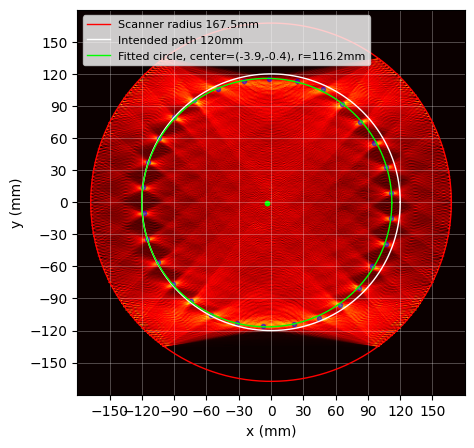

In [38]:
totalimg = np.zeros((360, 360))
xs, ys = [], []
for i in range(30):
    maxx, maxy = plot_img(boost(imgs[:, :, i]), 0, 'hcenterprojcut2', '', save = False)
    xs.append(maxx)
    ys.append(maxy)
    plt.plot(maxx, maxy, 'o', color = 'blue', markersize = 3, alpha = 0.5)
    totalimg += imgs[:, :, i]
plot_img(totalimg, 0, 'totalimg', '', save = False)
theta_circle = np.linspace(0, 2*np.pi, 500)
x_scanner = 167.5 * np.cos(theta_circle)
y_scanner = 167.5 * np.sin(theta_circle)
plt.plot(x_scanner, y_scanner, color='red', linewidth=1, label='Scanner radius 167.5mm')
x_path = 120 * np.cos(theta_circle)
y_path = 120 * np.sin(theta_circle)
plt.plot(x_path, y_path, color='white', linewidth=1, label='Intended path 120mm')
def fit_circle(xs, ys):
    A = np.c_[2*np.array(xs), 2*np.array(ys), np.ones(len(xs))]
    b = np.array(xs)**2 + np.array(ys)**2
    sol, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
    xc, yc, c = sol
    r = np.sqrt(c + xc**2 + yc**2)
    return xc, yc, r
xc, yc, rc = fit_circle(xs, ys)
theta = np.linspace(0, 2*np.pi, 300)
xx = xc + rc * np.cos(theta)
yy = yc + rc * np.sin(theta)
plt.plot(xx, yy, color='lime', linewidth=1, label = f'Fitted circle, center=({xc:.1f},{yc:.1f}), r={rc:.1f}mm')
plt.scatter(xc, yc, color='lime', s=10)
print(f"Circle fit: center=({xc:.1f},{yc:.1f}), r={rc:.1f}")
plt.grid(linewidth=0.4, color = 'white', alpha = 0.5)
plt.legend(framealpha = 0.8, loc = 'upper left', fontsize = 8)
plt.xlabel('x (mm)')
plt.ylabel('y (mm)')
plt.show()

/tmp/ipykernel_3680930/1816058075.py:31: UserWarning: Ignoring specified arguments in this call because figure with num: 0 already exists
  plt.figure(fignum, figsize = (5, 5))


-3.433333333333333


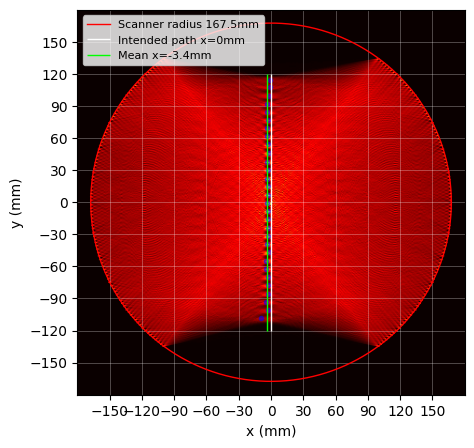

In [52]:
totalimg = np.zeros((360, 360))
xs, ys = [], []
for i in range(30):
    maxx, maxy = plot_img(boost(imgs[:, :, i]), 0, 'hcenterprojcut2', '', save = False)
    xs.append(maxx)
    ys.append(maxy)
    plt.plot(maxx, maxy, 'o', color = 'blue', markersize = 3, alpha = 0.5)
    totalimg += imgs[:, :, i]
plot_img(totalimg, 0, 'totalimg', '', save = False)
xs = np.array(xs)
print(np.mean(xs))
theta_circle = np.linspace(0, 2*np.pi, 500)
x_scanner = 167.5 * np.cos(theta_circle)
y_scanner = 167.5 * np.sin(theta_circle)
plt.plot(x_scanner, y_scanner, color='red', linewidth=1, label='Scanner radius 167.5mm')
plt.vlines(0, -120, 120, color = 'white', linewidth = 1, label = 'Intended path x=0mm')
plt.vlines(np.mean(xs), -120, 120, color = 'lime', linewidth = 1, label = f'Mean x={np.mean(xs):.1f}mm')
plt.grid(linewidth=0.4, color = 'white', alpha = 0.5)
plt.legend(framealpha = 0.8, loc = 'upper left', fontsize = 8)
plt.xlabel('x (mm)')
plt.ylabel('y (mm)')
plt.show()

100%|██████████| 96/96 [00:00<00:00, 220.60it/s]


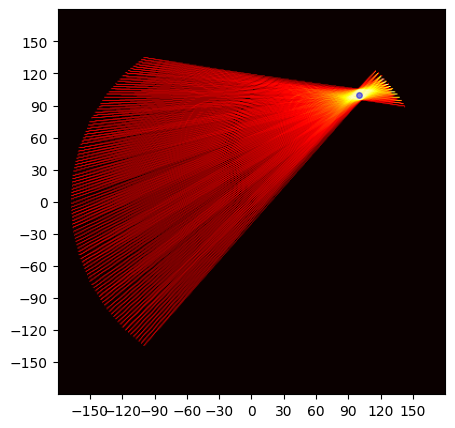

In [45]:
def lor_to_sinogram_coords(x1, y1, x2, y2):
    dx = x2 - x1
    dy = y2 - y1
    nx = -dy
    ny = dx
    norm = np.hypot(nx, ny)
    nx /= norm
    ny /= norm
    theta = np.arctan2(ny, nx)
    s = x1 * nx + y1 * ny
    if theta < 0:
        theta += np.pi
        s = -s
    elif theta >= np.pi:
        theta -= np.pi
        s = -s
    return theta, s
        
sourcepos = (100, 100)
testimg = np.zeros((360, 360))
for i in tqdm(range(96)):
    for j in range(96):
        theta, s = lor_to_sinogram_coords(topringL[i][0] - sourcepos[0], topringL[i][1] - sourcepos[1], topringR[j][0] - sourcepos[0], topringR[j][1] - sourcepos[1])
        if np.abs(s) < 5:
            testimg += siddon(topringL[i][0], topringL[i][1], topringR[j][0], topringR[j][1], xedges, yedges, 1)
plot_img(np.sqrt(testimg), 0, 'testimg', '')
plt.plot(sourcepos[0], sourcepos[1], 'o', color = 'blue', markersize = 4, alpha = 0.5)